#Mini Proyek : Story Telling with Data

Grafik yang bagus belum tentu **bercerita**.

Di mini-proyek ini kita berlatih **data storytelling**: menyusun beberapa grafik menjadi sebuah **narasi bisnis** yang jelas — *masalah → temuan → rekomendasi* — memakai data penjualan ritel Superstore.

> 🎯 **Tujuan Pembelajaran**


> - Memahami pola storytelling: **Situasi → Komplikasi → Temuan → Rekomendasi**.
> - Menyusun grafik berurutan yang saling mendukung sebuah pesan.
> - Menulis narasi yang menafsirkan grafik untuk audiens bisnis (bukan teknis).
> - Mengubah angka menjadi **rekomendasi yang bisa ditindaklanjuti**.

## Tentang Dataset

**Sample - Superstore**: data transaksi penjualan ritel sebuah toko serba ada di AS.

- **Sumber:** [Kaggle — vivek468/superstore-dataset-final](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)
- **Catatan teknis:** file CSV memakai encoding `latin-1` (bukan UTF-8 biasa).

| Kolom | Arti |
|-------|------|
| `Order Date` | Tanggal order |
| `Category` / `Sub-Category` | Kategori & sub-kategori produk |
| `Region` | Wilayah penjualan |
| `Segment` | Segmen pelanggan |
| `Sales` | Nilai penjualan ($) |
| `Profit` | Laba ($) |
| `Discount` | Diskon (0–1) |

## Import Library


- **pandas** → mengolah data transaksi.
- **matplotlib** & **seaborn** → membuat grafik untuk bercerita.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Import Dataset

In [3]:
!pip install -q kaggle
!kaggle datasets download -d vivek468/superstore-dataset-final

Dataset URL: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
License(s): other
100% 550k/550k [00:00<00:00, 669kB/s]



In [4]:
!unzip -q superstore-dataset-final.zip

## Explorasi awal Dataset

In [5]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


## Cleaning Data

Conversi `Order Date` menjadi bentuk datetime

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['month'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()
df['year'] = df['Order Date'].dt.to_period('Y').dt.to_timestamp()



In [11]:
print("rentang tanggal :", df['Order Date'].min().date(), "sampai", df['Order Date'].max().date())
print("missing tanggal :", df['Order Date'].isnull().sum())

rentang tanggal : 2014-01-03 sampai 2017-12-30
missing tanggal : 0


**Interpretasi:**

- Data mencakup beberapa tahun penjualan, tanpa tanggal yang gagal di-parse.

Sekarang kita siap menyusun narasi.

##Story Telling with Data

### Story 1 -  Omzet tumbuh dari waktu ke waktu

Pertama,Tren penjualan bulanan untuk memvalidasi optimisme manajemen

In [15]:
trend_M = df.groupby('month')['Sales'].sum()
trend_M.head()

,Sales
month,
2014-01-01,14236.895
2014-02-01,4519.892
2014-03-01,55691.009
2014-04-01,28295.345
2014-05-01,23648.287


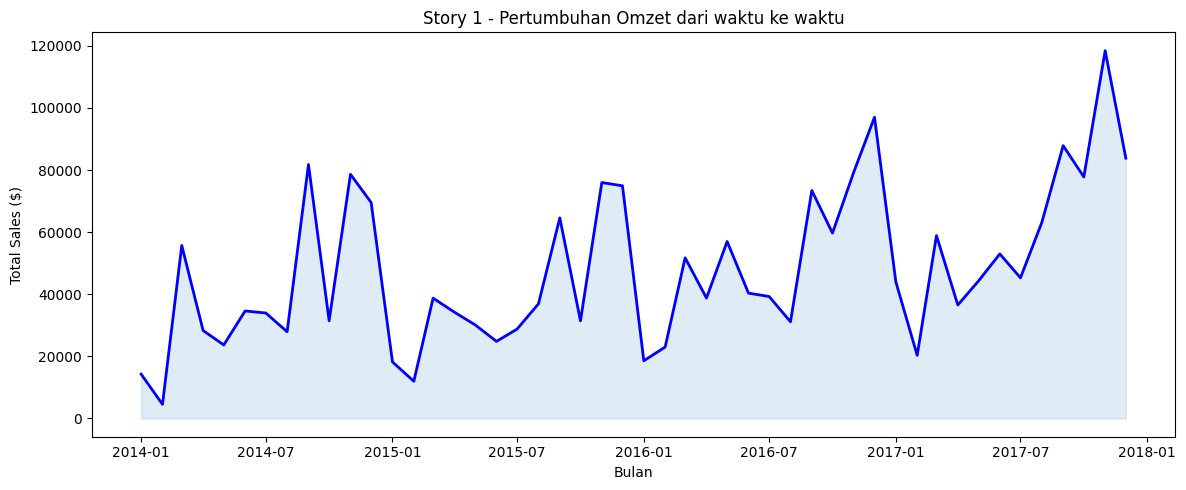

In [21]:
plt.figure(figsize=(12,5))

plt.plot(trend_M.index,
         trend_M.values,
         color="Blue",
         linewidth = 2)

plt.fill_between(trend_M.index, trend_M.values,alpha=0.15 , color="#2E86C1")
plt.title("Story 1 - Pertumbuhan Omzet dari waktu ke waktu")
plt.xlabel("Bulan")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

📈 **Narasi:**
- Benar, **omzet bertumbuh** dengan puncak-puncak di akhir tahun (musim liburan).
- Sekilas, bisnis terlihat sehat. Tapi omzet bukan laba — mari lanjut.

### Story 2 -  Laba yang tidak merata untuk setiap kategori

bandingkan Sales vs Profit per kategori produk.

In [29]:
cat = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
cat.round(0)

,Sales,Profit
Category,,
Technology,836154.0,145455.0
Furniture,742000.0,18451.0
Office Supplies,719047.0,122491.0


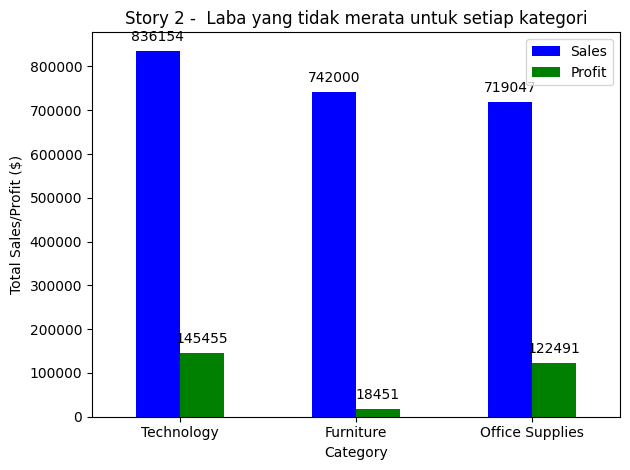

In [30]:
ax = cat.plot(kind="bar", color=["blue", "green"])

plt.title("Story 2 -  Laba yang tidak merata untuk setiap kategori")
plt.xticks(rotation=0)
plt.ylabel("Total Sales/Profit ($)")
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 10),
                   textcoords = 'offset points')

plt.tight_layout()
plt.show()


⚖️ **Narasi:**
  - Kategori **Technology** dan **Office Supplies** sehat.
  - **Furniture** punya Sales besar tetapi **Profit-nya sangat tipis** — tanda ada masalah tersembunyi di dalamnya.

### Story 3 -  Laba Merugi pada beberapa Sub - Kategori

Mari bedah lebih dalam: sub-kategori mana yang labanya negatif?

In [34]:
sub_cat = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)
sub_cat

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


Terdapat beberapa sub-categori yang mengalami kerugian

In [36]:
color = ["#C0392B" if v < 0 else "#28B463" for v in sub_cat.values]

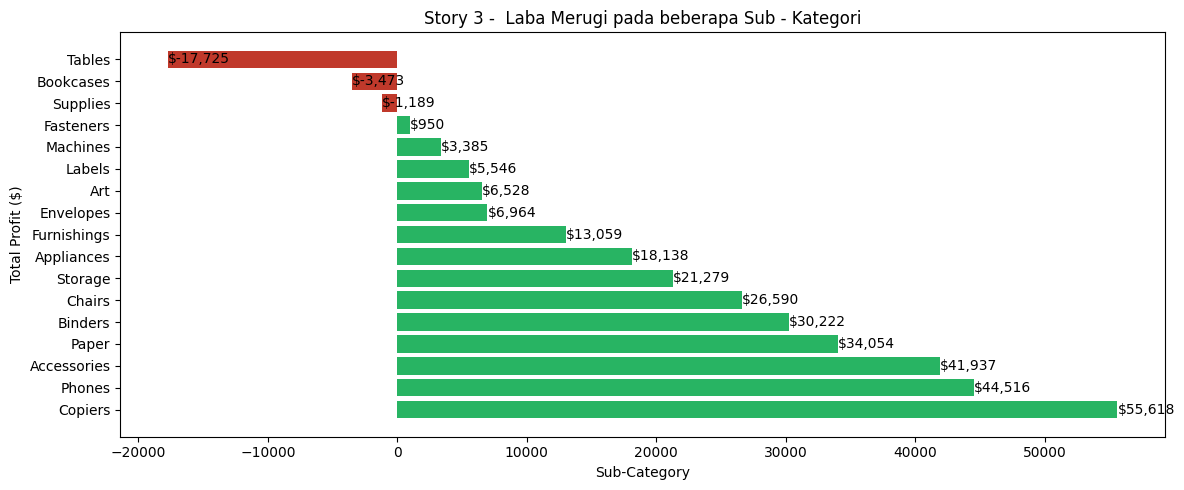

In [41]:
plt.figure(figsize=(12,5))
plt.barh(sub_cat.index, sub_cat.values, color=color)
plt.title("Story 3 -  Laba Merugi pada beberapa Sub - Kategori")
for i, v in enumerate(sub_cat.values):
    plt.text(v, i, f"${v:,.0f}", va="center")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit ($)")
plt.tight_layout()
plt.show()

🔴 **Narasi:**
- Inilah Penyebabnya! Sub-kategori **Tables**, **Bookcases**, dan **Supplies**
membukukan **kerugian** (batang merah).
- Padahal mereka tetap dijual dan menyedot biaya.


Pertanyaannya: kenapa?

### Story 4 - Menemukan akar permasalahan penyebab kerugian

  Hipotesa sementara : Adanya diskon besar membuat margin negatif.

  - Lakukan pengujian Discount vs Profit

In [46]:
diskon_profit_mean = df.groupby("Discount")["Profit"].mean()
diskon_profit_mean

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.679636
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


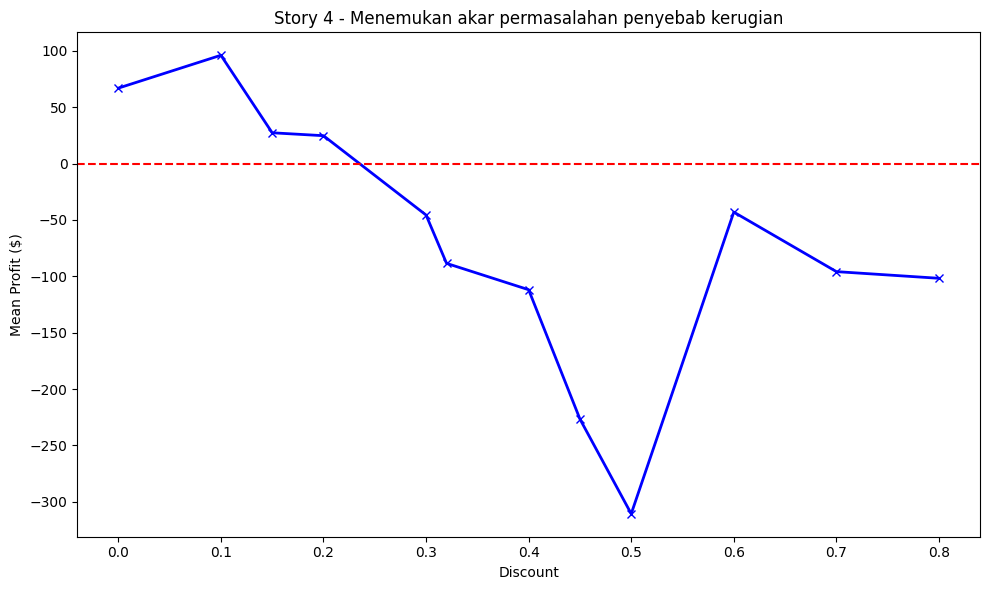

In [52]:
plt.figure(figsize=(10,6))

plt.plot(diskon_profit_mean.index,
         diskon_profit_mean.values,
         color="Blue",
         marker="x",
         linewidth = 2)

plt.axhline(y=0, color='r', linestyle='--')
plt.title("Story 4 - Menemukan akar permasalahan penyebab kerugian")
plt.xlabel("Discount")
plt.ylabel("Mean Profit ($)")
plt.tight_layout()
plt.show()


💡 **Narasi:**
  - Polanya jelas: **begitu diskon melewati ~20%, rata-rata profit jatuh ke bawah nol**.
  
- Diskon agresif adalah akar kerugian — bukan masalah permintaan, tapi masalah penetapan harga.

### Story 5 - Peta Wilayah - menentukan wilayah mana yang paling sehat

In [56]:
pivot = df.pivot_table(index="Region",
                       columns="Category",
                       values="Profit",
                       aggfunc="sum")
pivot.round(1)

Category,Furniture,Office Supplies,Technology
Region,,,
Central,-2871.0,8880.0,33697.4
East,3046.2,41014.6,47462.0
South,6771.2,19986.4,19991.8
West,11505.0,52609.8,44303.6


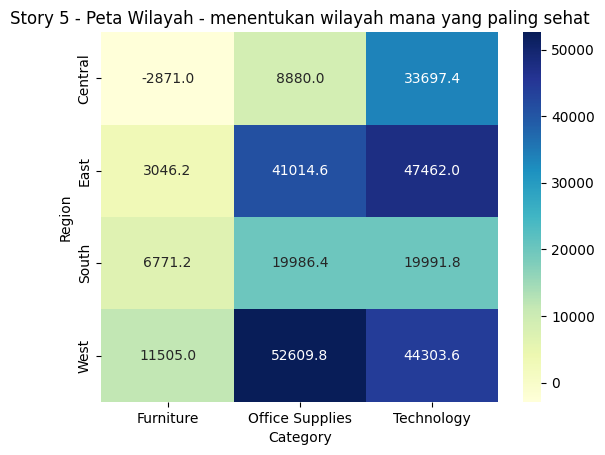

In [59]:
sns.heatmap(pivot,
            annot=True,
            cmap="YlGnBu",
            fmt=".1f")
plt.xticks(rotation=0)
plt.title("Story 5 - Peta Wilayah - menentukan wilayah mana yang paling sehat")
plt.show()

🗺️ **Narasi:**
- Wilayah **Central** lemah, terutama pada Furniture,
- sementara **West** dan **East** paling sehat.

Ini memberi tahu manajemen di mana harus memperbaiki strategi diskon lebih dulu.

## Kesimpulan dan Insight

Rangkaian cerita data membawa kita dari optimisme menuju tindakan konkret:

1. **Omzet tumbuh**, tetapi pertumbuhan tidak otomatis berarti untung.
2. Kategori **Furniture** — khususnya sub-kategori **Tables, Bookcases, Supplies** — **merugi**.
3. Akar masalahnya: **diskon di atas ~20% menggerus laba** hingga negatif.
4. Wilayah **Central** paling terdampak.

**Rekomendasi untuk manajemen:**
- **Batasi diskon maksimum** untuk Furniture (mis. ≤ 20%).
- **Evaluasi ulang** sub-kategori Tables/Bookcases: negosiasi biaya, naikkan harga, atau hentikan SKU rugi.
- **Fokuskan perbaikan** di wilayah Central terlebih dahulu

### ⚠️ Jebakan Data (Etika Storytelling)

Storytelling yang kuat membawa tanggung jawab:

- **jangan cherry-picking** — memilih hanya data/rentang waktu yang mendukung narasi sambil menyembunyikan yang tidak.
- Cerita yang baik tetap **jujur pada data utuh**
- Tunjukkan juga konteks yang melemahkan argumen agar rekomendasi yang diberikan kredibel dan tahan uji.